In [1]:
# imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import heapq
import itertools
from typing import Callable
import time

np.random.seed(1234)

stations = ["G", "L", "B", "Z"]
station_to_idx = {s: i for i, s in enumerate(stations)}

# Demand rates during peak periods [1000 passengers/h]
demand_peak = np.array(
    [
        [np.nan, 1.5, 2.2, 1.3],
        [np.nan, np.nan, 2.4, 1.1],
        [np.nan, np.nan, np.nan, 3.3],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Demand rates during off-peak periods [1000 passengers/h]
demand_offpeak = np.array(
    [
        [np.nan, 0.4, 0.3, 0.5],
        [np.nan, np.nan, 0.5, 0.3],
        [np.nan, np.nan, np.nan, 0.5],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during peak periods
first_class_ratio_peak = np.array(
    [
        [np.nan, 0.13, 0.15, 0.17],
        [np.nan, np.nan, 0.21, 0.18],
        [np.nan, np.nan, np.nan, 0.32],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during off-peak periods
first_class_ratio_offpeak = np.array(
    [
        [np.nan, 0.21, 0.18, 0.23],
        [np.nan, np.nan, 0.24, 0.23],
        [np.nan, np.nan, np.nan, 0.19],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

df_demand_peak = pd.DataFrame(demand_peak, index=stations, columns=stations)
df_demand_offpeak = pd.DataFrame(demand_offpeak, index=stations, columns=stations)
df_first_class_ratio_peak = pd.DataFrame(
    first_class_ratio_peak, index=stations, columns=stations
)
df_first_class_ratio_offpeak = pd.DataFrame(
    first_class_ratio_offpeak, index=stations, columns=stations
)

In [2]:
def exponential_rng(lam: float, u: float):
    """Generates exponential random number."""
    if lam <= 0:
        return float("inf")
    return -np.log(u) / lam


# Price constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10
PASSENGER_PEAK_TIMES = (
    (420, 540),
    (960, 1080),
)  # Default peak times: 7-9 and 16-18


def get_travel_time(station):
    """Returns the travel time to the next station in minutes"""
    if station == "G":
        return 40
    if station == "L":
        return 70
    if station == "B":
        return 60
    return 0


def get_num_stations(origin, destination):
    return station_to_idx[destination] - station_to_idx[origin]


def is_peak(time_minutes, peak_times=((420, 540), (960, 1080))):
    """Checks if we are in peak hours (7-9 or 16-18)"""
    time_of_day = time_minutes % (24 * 60)
    # 7:00 = 420, 9:00 = 540, 16:00 = 960, 18:00 = 1080
    if peak_times is not None:
        for start, end in peak_times:
            if start <= time_of_day <= end:
                return True
        return False

In [3]:
class Passenger:
    def __init__(self, arrival_time, origin, destination, is_first_class):
        self.arrival_time = arrival_time
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class
        self.missed_trains = 0


max_number_of_carriages = 6


@dataclass
class TrainType:
    """Train can have a maximum number of six carriages"""

    name: str
    first_class_carriages: int
    second_class_carriages: int

    def __repr__(self):
        return f"{self.name}"

    def __post__init__(self):
        if (
            self.first_class_carriages + self.second_class_carriages
            > max_number_of_carriages
        ):
            raise ValueError(f"Total carriages cannot exceed {max_number_of_carriages}")
        if self.first_class_carriages < 0 or self.second_class_carriages < 0:
            raise ValueError("Carriage numbers cannot be negative")


@dataclass
class Train:
    train_id: int
    # Standard composition: 1 first class (300) and 3 second class (1500)
    train_type: TrainType

    # Lists to keep track of passengers on board
    onboard_first: list = None
    onboard_second: list = None

    def __post_init__(self):
        self.onboard_first = []
        self.onboard_second = []

    @property
    def capacity_first(self):
        return self.train_type.first_class_carriages * 300

    @property
    def capacity_second(self):
        return self.train_type.second_class_carriages * 500

In [4]:
from dataclasses import dataclass


@dataclass
class Event:
    """Generic event."""

    time: float


class PassengerGeneration(Event):
    """A passenger arrives at the station"""

    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class


@dataclass
class TrainArrival(Event):
    """The train arrives at a station"""

    station: str
    train: Train


In [5]:
def get_arrival_rate(origin, destination, time):
    """Arrival rate in passengers per minute for a route."""
    i = station_to_idx[origin]
    j = station_to_idx[destination]

    if is_peak(time):
        demand = demand_peak
    else:
        demand = demand_offpeak

    total_demand_per_hour = demand[i, j] * 1000

    if np.isnan(total_demand_per_hour):
        return 0.0

    return total_demand_per_hour / 60.0


def draw_passenger_class(origin, destination, time):
    """
    Returns True for first class, False for second class.
    Class is assigned by drawing U ~ Uniform(0,1).
    """
    i = station_to_idx[origin]
    j = station_to_idx[destination]

    if is_peak(time):
        first_ratio = first_class_ratio_peak[i, j]
    else:
        first_ratio = first_class_ratio_offpeak[i, j]

    u = np.random.rand()
    return u < first_ratio


def generate_timetable(
    freq_peak, freq_offpeak
):  # Generates all train arrival events for the day
    train_events = []
    t = 0
    train_id = 0

    while t < 24 * 60:
        train = Train(train_id)
        current_time = t

        # Make the train travel through the stations
        for station in stations:
            train_events.append(TrainArrival(current_time, station, train))
            current_time += get_travel_time(station)

        if is_peak(t):
            t += freq_peak
        else:
            t += freq_offpeak

        train_id += 1

    return train_events

In [6]:
from dataclasses import dataclass


base_train = TrainType(name="base", first_class_carriages=1, second_class_carriages=3)
short_train = TrainType(name="short", first_class_carriages=1, second_class_carriages=1)
long_train = TrainType(name="long", first_class_carriages=2, second_class_carriages=5)


def t_in_intervals(t, intervals: list[tuple[float]] | None):
    """Checks if time t is within any of the given intervals"""
    return any(start <= t <= end for start, end in intervals or [])


@dataclass
class Scenario:
    train_frequency_peak: float
    train_frequency_offpeak: float
    train_config_1: TrainType
    train_config_2: TrainType | None = None
    train_config_3: TrainType | None = None  # maximum 3 types
    train_type_2_intervals: list[tuple[float]] = None
    train_type_3_intervals: list[tuple[float]] = None
    peak_times: list[tuple[float]] = (
        (420, 540),
        (960, 1080),
    )  # Default peak times: 7-9 and 16-18

    def get_timetable(
        self,
        sorted_by_time: bool = True,
    ) -> list[TrainArrival]:
        train_events = []
        t = 0
        train_id = 0

        while t < 24 * 60:
            train_type = self.train_config_1
            if t_in_intervals(t, self.train_type_2_intervals):
                train_type = self.train_config_2
            elif t_in_intervals(t, self.train_type_3_intervals):
                train_type = self.train_config_3

            train = Train(
                train_id=train_id,
                train_type=train_type,
            )
            current_time = t

            # Make the train travel through the stations
            for station in stations:
                train_events.append(TrainArrival(current_time, station, train))
                current_time += get_travel_time(station)

            if is_peak(t):
                t += self.train_frequency_peak
            else:
                t += self.train_frequency_offpeak

            train_id += 1
        if sorted_by_time:
            train_events.sort(key=lambda event: event.time)
        return train_events

    def __str__(self):
        return f"Peak frequency: {self.train_frequency_peak} min, Off-peak frequency: {self.train_frequency_offpeak} min"

    @classmethod
    def create(
        cls,
        peak_frequency: float,
        non_peak_frequency: float,
        # of carriages
        train1_first_class_carriages: int,
        train1_second_class_carriages: int,
        # train2_first_class_carriages: int,
        # train2_second_class_carriages: int,
        # train3_first_class_carriages: int,
        # train3_second_class_carriages: int,
        #
        # pre-post-peak times in minutes
        first_pre_peak_time_in_minutes: float = 0,
        first_post_peak_time_in_minutes: float = 0,
        second_pre_peak_time_in_minutes: float = 0,
        second_post_peak_time_in_minutes: float = 0,
    ):
        return cls(
            train_frequency_peak=peak_frequency,
            train_frequency_offpeak=non_peak_frequency,
            train_config_1=TrainType(
                name="train1",
                first_class_carriages=train1_first_class_carriages,
                second_class_carriages=train1_second_class_carriages,
            ),
            # train_config_2=TrainType(
            #     name="train2",
            #     first_class_carriages=train2_first_class_carriages,
            #     second_class_carriages=train2_second_class_carriages,
            # ),
            # train_config_3=TrainType(
            #     name="train3",
            #     first_class_carriages=train3_first_class_carriages,
            #     second_class_carriages=train3_second_class_carriages,
            # ),
            peak_times=[
                (
                    PASSENGER_PEAK_TIMES[0][0] - first_pre_peak_time_in_minutes,
                    PASSENGER_PEAK_TIMES[0][1] + first_post_peak_time_in_minutes,
                ),
                (
                    PASSENGER_PEAK_TIMES[1][0] - second_pre_peak_time_in_minutes,
                    PASSENGER_PEAK_TIMES[1][1] + second_post_peak_time_in_minutes,
                ),
            ],
        )


@dataclass
class SimulationResult:
    time_history: list[int]
    queue_history: list[int]
    waiting_times: list[float]
    total_revenue: float
    total_missed_cost: float
    total_empty_cost: float
    list_available_first: list[int]
    list_available_second: list[int]
    times_available_first: list[float]
    times_available_second: list[float]
    runtime_s: float

    def print_summary(self):
        print(f"Passengers served: {len(self.waiting_times):,.2f}")
        print(f"Average waiting time: {np.mean(self.waiting_times):.2f} minutes")
        print(f"Total revenue: {self.total_revenue:,.2f} CHF")
        print(f"Missed passenger costs: {self.total_missed_cost:,.2f} CHF")
        print(f"Empty seat costs: {self.total_empty_cost:,.2f} CHF")
        profit = self.total_revenue - self.total_missed_cost - self.total_empty_cost
        print(f"NET PROFIT: {profit:,.2f} CHF\n")
        print(f"Runtime: {self.runtime_s:.2f} seconds")

    def get_statistics(self):
        """Returns
        - net profit
        - mean waiting time
        - max waiting time
        """
        net_profit = self.total_revenue - self.total_missed_cost - self.total_empty_cost
        mean_waiting_time = np.mean(self.waiting_times).item()
        max_waiting_time = np.max(self.waiting_times).item()
        return net_profit, mean_waiting_time, max_waiting_time

    def __repr__(self):
        return f"Result(runtime_s={self.runtime_s:.2f} s, Net profit={self.total_revenue - self.total_missed_cost - self.total_empty_cost:,.2f} CHF)"

In [7]:
def simulate_one_scenario(scenario: Scenario, u: np.ndarray) -> SimulationResult:
    # Initialize queues at stations
    start = time.time()
    queues = {s: {"first": [], "second": []} for s in stations}

    # Priority queue for events: (time, tie_breaker, event)
    event_heap = []
    counter = itertools.count()
    i_arr = 0

    def push_event(event):
        heapq.heappush(event_heap, (event.time, next(counter), event))

    # Push all train arrivals
    for event in scenario.get_timetable(sorted_by_time=False):
        push_event(event)

    # Generate first passenger arrival event for each OD pair
    for i, origin in enumerate(stations):
        for j, destination in enumerate(stations):
            if i >= j:
                continue

            rate = get_arrival_rate(origin, destination, 0.0)
            if rate > 0:
                t_first = exponential_rng(rate, u[i_arr])
                is_first = draw_passenger_class(origin, destination, t_first)
                push_event(PassengerGeneration(t_first, origin, destination, is_first))
                i_arr += 1

    # State variables and statistics
    total_revenue = 0.0
    total_missed_cost = 0.0
    total_empty_cost = 0.0
    waiting_times = []

    time_history = []
    queue_history = []
    list_available_first = []
    list_available_second = []
    times_available_first = []
    times_available_second = []

    current_total_queue = 0

    while event_heap:
        _, _, e = heapq.heappop(event_heap)

        if e.time > 24 * 60:
            break

        if isinstance(e, PassengerGeneration):
            # Add passenger to queue
            p = Passenger(e.time, e.origin, e.destination, e.is_first_class)
            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)
            current_total_queue += 1

            # Schedule next passenger generation for this OD pair
            rate = get_arrival_rate(e.origin, e.destination, e.time)
            if rate > 0:
                next_time = e.time + exponential_rng(rate, u[i_arr])
                next_is_first = draw_passenger_class(e.origin, e.destination, next_time)
                push_event(
                    PassengerGeneration(
                        next_time, e.origin, e.destination, next_is_first
                    )
                )
                i_arr += 1

        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station

            # Passengers get off
            train.onboard_first = [
                p for p in train.onboard_first if p.destination != station
            ]
            train.onboard_second = [
                p for p in train.onboard_second if p.destination != station
            ]

            # Passengers board
            if station != "Z":
                # First class boarding
                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []

                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        current_total_queue -= 1

                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_FIRST * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)

                queues[station]["first"] = left_behind_first
                total_empty_cost += available_first * EMPTY_COST_FIRST
                list_available_first.append(available_first)
                times_available_first.append(e.time)

                # Second class boarding
                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []

                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        current_total_queue -= 1

                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_SECOND * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)

                queues[station]["second"] = left_behind_second
                total_empty_cost += available_second * EMPTY_COST_SECOND
                list_available_second.append(available_second)
                times_available_second.append(e.time)

        time_history.append(e.time)
        queue_history.append(current_total_queue)
        end = time.time()

    return SimulationResult(
        time_history=time_history,
        queue_history=queue_history,
        waiting_times=waiting_times,
        total_revenue=total_revenue,
        total_missed_cost=total_missed_cost,
        total_empty_cost=total_empty_cost,
        list_available_first=list_available_first,
        list_available_second=list_available_second,
        times_available_first=times_available_first,
        times_available_second=times_available_second,
        runtime_s=end - start,
    )

In [8]:
def bootstrap_function(data: np.ndarray, f_statistic: Callable, draws: int) -> float:
    """Calculates the bootstrap mse of a statistic of choice

    Keywords:
        data (array): data array.
        f_statistic: function handle calculating the statistic of interest.
        draws (int): number of bootstrap draws.

    Returns:
        mse (float): mean square error of the statistic of interest.
    """
    theta = f_statistic(data)
    emp_stats = np.zeros((draws,))
    se = np.zeros((draws,))
    for d in np.arange(draws):
        # this is a bootstrap sample
        data_draw = np.random.choice(data, size=data.shape[0], replace=True)
        # statistic is calculated using the bootstrap sample
        theta_emp = f_statistic(data_draw)
        emp_stats[d] = theta_emp
        # squared error is calculated between true value and estimate
        se[d] = (theta_emp - theta) ** 2
    return se.mean()

In [9]:
### statistic functions (mean, variance, quantiles, worst case)
def q025(x):
    return np.quantile(x, 0.025)


def q975(x):
    return np.quantile(x, 0.975)


def worst(x):
    return np.max(x)


def mean_stat(x):
    return np.mean(x)


def var_stat(x):
    return np.var(x, ddof=1)

In [10]:
def simulate(
    seed: int,
    scenario: Scenario,
    min_runs: int = 1000,
    rng_size: int = 100000,
    precision_percent: float = 1.0,
    antithetic: bool = True,
    verbose: bool = True,
):
    """
    Returns:
    - mean of net profit
    - mean of mean of waiting times
    - mean of maximum waiting time
    """
    # Convergence parameters
    rng = np.random.default_rng(seed)

    # Initialize statistics tracking
    statistics = []
    num_runs_ind = 0

    # Main simulation loop with convergence checking
    print("Running queue simulations with independent sampling...")
    while num_runs_ind < min_runs:
        num_runs_ind += 1

        # Generate random numbers and run simulation
        u = rng.random(rng_size)
        result = simulate_one_scenario(scenario=scenario, u=u)
        statistics.append(result.get_statistics())

        if antithetic:
            num_runs_ind += 1
            u_antithetic = 1 - u
            result_antithetic = simulate_one_scenario(scenario=scenario, u=u_antithetic)
            statistics.append(result_antithetic.get_statistics())

        # Check convergence: Standard Error of Mean (SEM) < PRECISION
        # SEM = sqrt(Var / n)
        convergence_statistic_id = 0
        convergence_statistic = np.array(statistics)[:, convergence_statistic_id]

        sem_cost = np.sqrt(convergence_statistic.var() / num_runs_ind)
        mse_cost = bootstrap_function(convergence_statistic, mean_stat, draws=1000)

        sem_mean_waiting_time = np.sqrt(
            np.var(np.array(statistics)[:, 1]) / num_runs_ind
        )
        mse_mean_waiting_time = bootstrap_function(
            np.array(statistics)[:, 1], mean_stat, draws=1000
        ).item()

        sem_max_waiting_time = np.sqrt(
            np.var(np.array(statistics)[:, 2]) / num_runs_ind
        )
        mse_max_waiting_time = bootstrap_function(
            np.array(statistics)[:, 2], mean_stat, draws=1000
        ).item()

        # Print progress every 10 runs
        if num_runs_ind % 10 == 0:
            sem = np.sqrt(convergence_statistic.var() / num_runs_ind)
            if verbose:
                print(
                    f"  Run {num_runs_ind:3d}: Mean = {convergence_statistic.mean():.2f}, SEM = {sem:.4f}, error in % {sem / convergence_statistic.mean() * 100:.2f}%"
                )

    return np.array(statistics), {
        "net_profit": {
            "mean": np.mean(convergence_statistic).item(),
            "sem": sem_cost,
            "bootstrap_mse": mse_cost,
            "error_percent": (sem_cost / convergence_statistic.mean() * 100).item(),
        },
        "mean_waiting_time": {
            "mean": np.mean(np.array(statistics)[:, 1]).item(),
            "sem": sem_mean_waiting_time,
            "bootstrap_mse": mse_mean_waiting_time,
            "error_percent": (
                sem_cost / np.mean(np.array(statistics)[:, 1]) * 100
            ).item(),
        },
        "max_waiting_time": {
            "mean": np.mean(np.array(statistics)[:, 2]).item(),
            "sem": sem_max_waiting_time,
            "bootstrap_mse": mse_max_waiting_time,
            "error_percent": (
                sem_cost / np.mean(np.array(statistics)[:, 2]) * 100
            ).item(),
        },
    }

    return None

## Examples of simulations

**It seems like max wait time cannot get lower than 109! Because of the first trains probably!**

In [11]:
# example scenarios

scenario_1 = Scenario(
    train_frequency_peak=20,
    train_frequency_offpeak=20,
    train_config_1=base_train,
)

scenario_2 = Scenario(
    train_frequency_peak=15,
    train_frequency_offpeak=30,
    train_config_1=base_train,
)

scenario_train_every_minute = Scenario(
    train_frequency_peak=1,
    train_frequency_offpeak=1,
    train_config_1=base_train,
)

scenario_train_every_minute = Scenario(
    train_frequency_peak=1,
    train_frequency_offpeak=1,
    train_config_1=base_train,
)

scenario_different_peak_times = Scenario.create(
    peak_frequency=15,
    non_peak_frequency=30,
    train1_first_class_carriages=1,
    train1_second_class_carriages=3,
    first_pre_peak_time_in_minutes=30,
    second_pre_peak_time_in_minutes=30,
)

statistics = [[] for _ in range(4)]
queue_history = [[] for _ in range(4)]
time_history = [[] for _ in range(4)]
for idx, scenario in enumerate(
    [scenario_1, scenario_2, scenario_train_every_minute, scenario_different_peak_times]
):
    print(f"Running scenario: {scenario}")
    result = simulate_one_scenario(scenario, u=np.random.rand(100000))
    statistics[idx] = result.get_statistics()
    queue_history[idx] = result.queue_history
    time_history[idx] = result.time_history


Running scenario: Peak frequency: 20 min, Off-peak frequency: 20 min
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min
Running scenario: Peak frequency: 1 min, Off-peak frequency: 1 min
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min


Scenario 1
Net profit: 5.88e+05 CHF
Mean waiting time: 15.54
Max waiting time: 109.84

Scenario 2
Net profit: 1.42e+06 CHF
Mean waiting time: 16.92
Max waiting time: 112.21

Scenario 3 (Train every minute)
Net profit: -8.21e+07 CHF
Mean waiting time: 1.11
Max waiting time: 109.88

Scenario 4 (Different peak times)
Net profit: 1.40e+06 CHF
Mean waiting time: 17.03
Max waiting time: 116.74



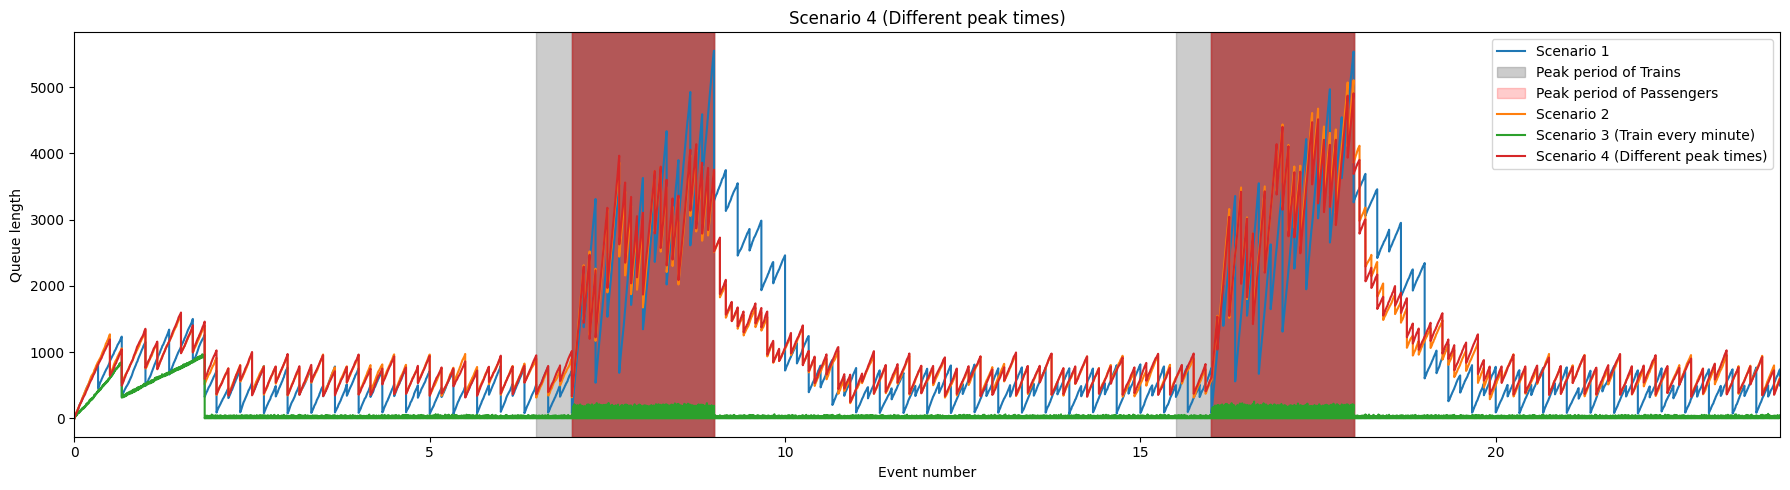

In [12]:
fig, axes = plt.subplots(figsize=(18, 5), sharey=True)
axes = [axes]

for idx, (name, scenario_stats, qh, th, peak_times) in enumerate(
    zip(
        [
            "Scenario 1",
            "Scenario 2",
            "Scenario 3 (Train every minute)",
            "Scenario 4 (Different peak times)",
        ],
        statistics,
        queue_history,
        time_history,
        [
            scenario.peak_times
            for scenario in [
                scenario_1,
                scenario_2,
                scenario_train_every_minute,
                scenario_different_peak_times,
            ]
        ],
    )
):
    print(name)
    scenario_stats = np.array(scenario_stats)
    print(f"Net profit: {np.mean(scenario_stats[0]).item():.2e} CHF")
    print(f"Mean waiting time: {np.mean(scenario_stats[1]).item():.2f}")
    print(f"Max waiting time: {np.mean(scenario_stats[2]).item():.2f}")
    print()
    axes[0].plot(np.array(th) / 60, qh, label=name)
    axes[0].set_title(name)
    axes[0].set_xlabel("Event number")
    axes[0].set_ylabel("Queue length")
    axes[0].set_xlim(0, 24)
    for idx_peaks, (peak_start, peak_end) in enumerate(peak_times):
        peak_start_hours = peak_start / 60
        peak_end_hours = peak_end / 60
        axes[0].axvspan(
            peak_start_hours,
            peak_end_hours,
            color="gray",
            alpha=0.4,
            label="Peak period of Trains" if idx == 0 and idx_peaks == 0 else None,
        )
    for idx_peaks, (peak_start, peak_end) in enumerate(PASSENGER_PEAK_TIMES):
        peak_start_hours = peak_start / 60
        peak_end_hours = peak_end / 60
        axes[0].axvspan(
            peak_start_hours,
            peak_end_hours,
            color="red",
            alpha=0.2,
            label="Peak period of Passengers" if idx == 0 and idx_peaks == 0 else None,
        )
    axes[0].legend()
plt.tight_layout()


## Simulate one scenario for many draws

We already included antithetic draws as variance reduction and calculate the bootstrapped mse (Need to fix something)

In [13]:
statistics, result = simulate(
    seed=1234,
    scenario=scenario_different_peak_times,
    min_runs=500,
    rng_size=100000,
    antithetic=False,
)
statistics_antithetic, result_antithetic = simulate(
    seed=1234,
    scenario=scenario_different_peak_times,
    min_runs=500,
    rng_size=100000,
    antithetic=True,
)

Running queue simulations with independent sampling...
  Run  10: Mean = 1415281.00, SEM = 3713.5319, error in % 0.26%
  Run  20: Mean = 1410123.00, SEM = 4815.7249, error in % 0.34%
  Run  30: Mean = 1410051.33, SEM = 4039.8788, error in % 0.29%
  Run  40: Mean = 1412375.25, SEM = 3727.5198, error in % 0.26%
  Run  50: Mean = 1413817.60, SEM = 3406.2562, error in % 0.24%
  Run  60: Mean = 1412982.67, SEM = 3149.0586, error in % 0.22%
  Run  70: Mean = 1412081.43, SEM = 2811.7665, error in % 0.20%
  Run  80: Mean = 1409942.25, SEM = 2761.3248, error in % 0.20%
  Run  90: Mean = 1410720.56, SEM = 2520.3225, error in % 0.18%
  Run 100: Mean = 1411468.50, SEM = 2530.4494, error in % 0.18%
  Run 110: Mean = 1411620.09, SEM = 2398.7286, error in % 0.17%
  Run 120: Mean = 1411132.83, SEM = 2229.5638, error in % 0.16%
  Run 130: Mean = 1411840.15, SEM = 2129.7536, error in % 0.15%
  Run 140: Mean = 1412238.57, SEM = 2088.4578, error in % 0.15%
  Run 150: Mean = 1412740.80, SEM = 1999.8178, er

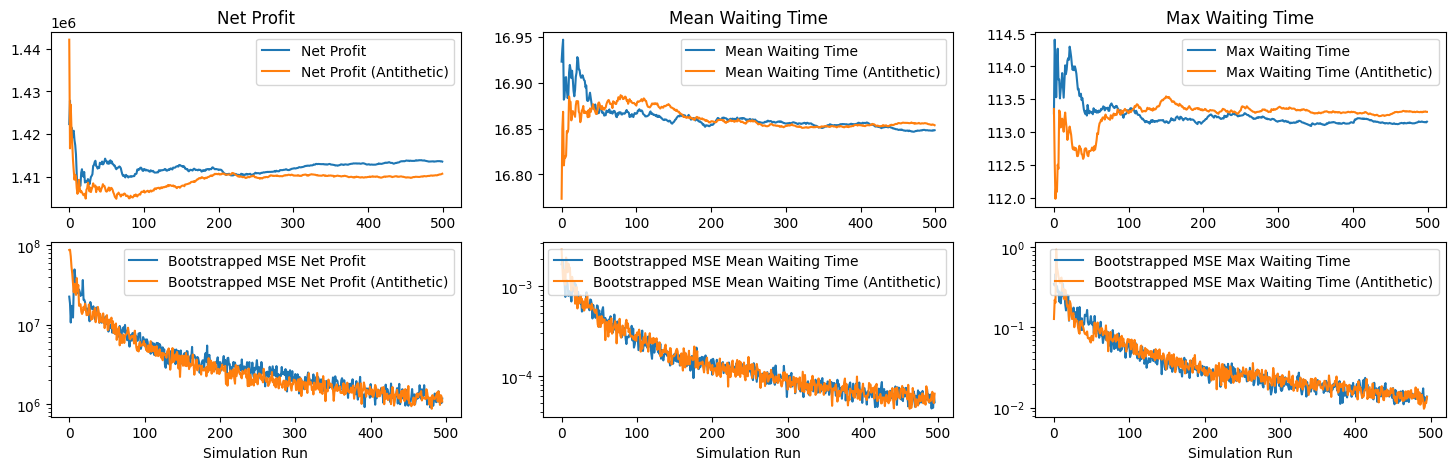

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
ax1, ax2, ax3 = axes[0, 0], axes[0, 1], axes[0, 2]
ax4, ax5, ax6 = axes[1, 0], axes[1, 1], axes[1, 2]

ax1.plot(
    [np.mean(statistics[:, 0][:i]) for i in range(1, len(statistics[:, 0]) + 1)],
    label="Net Profit",
)
ax1.plot(
    [
        np.mean(statistics_antithetic[:, 0][:i])
        for i in range(1, len(statistics_antithetic[:, 0]) + 1)
    ],
    label="Net Profit (Antithetic)",
)
ax2.plot(
    [np.mean(statistics[:, 1][:i]) for i in range(1, len(statistics[:, 1]) + 1)],
    label="Mean Waiting Time",
)
ax2.plot(
    [
        np.mean(statistics_antithetic[:, 1][:i])
        for i in range(1, len(statistics_antithetic[:, 1]) + 1)
    ],
    label="Mean Waiting Time (Antithetic)",
)
ax3.plot(
    [np.mean(statistics[:, 2][:i]) for i in range(1, len(statistics[:, 2]) + 1)],
    label="Max Waiting Time",
)
ax3.plot(
    [
        np.mean(statistics_antithetic[:, 2][:i])
        for i in range(1, len(statistics_antithetic[:, 2]) + 1)
    ],
    label="Max Waiting Time (Antithetic)",
)
ax1.set_title("Net Profit")
ax2.set_title("Mean Waiting Time")
ax3.set_title("Max Waiting Time")

# now plot bootstrapped mean
ax4.plot(
    [
        bootstrap_function(statistics[:, 0][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 0]) + 1)
    ],
    label="Bootstrapped MSE Net Profit",
)
ax4.plot(
    [
        bootstrap_function(
            statistics_antithetic[:, 0][:i], f_statistic=np.mean, draws=100
        )
        for i in range(5, len(statistics_antithetic[:, 0]) + 1)
    ],
    label="Bootstrapped MSE Net Profit (Antithetic)",
)
ax5.plot(
    [
        bootstrap_function(statistics[:, 1][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 1]) + 1)
    ],
    label="Bootstrapped MSE Mean Waiting Time",
)
ax5.plot(
    [
        bootstrap_function(
            statistics_antithetic[:, 1][:i], f_statistic=np.mean, draws=100
        )
        for i in range(5, len(statistics_antithetic[:, 1]) + 1)
    ],
    label="Bootstrapped MSE Mean Waiting Time (Antithetic)",
)
ax6.plot(
    [
        bootstrap_function(statistics[:, 2][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 2]) + 1)
    ],
    label="Bootstrapped MSE Max Waiting Time",
)
ax6.plot(
    [
        bootstrap_function(
            statistics_antithetic[:, 2][:i], f_statistic=np.mean, draws=100
        )
        for i in range(5, len(statistics_antithetic[:, 2]) + 1)
    ],
    label="Bootstrapped MSE Max Waiting Time (Antithetic)",
)
for ax in [ax1, ax2, ax3]:
    ax.legend()
for ax in [ax4, ax5, ax6]:
    ax.legend()
    ax.set_xlabel("Simulation Run")
    ax.set_yscale("log")

## Optimization

In [15]:
# dummy optimization loop to show how it could be used
range_pre_peak = np.linspace(0, 120, 3)

scenario_params = [
    {
        "peak_frequency": 15,
        "non_peak_frequency": 30,
        "train1_first_class_carriages": 1,
        "train1_second_class_carriages": 3,
        "first_pre_peak_time_in_minutes": pre_preak_time,
        "second_pre_peak_time_in_minutes": pre_preak_time,
    }
    for pre_preak_time in range_pre_peak
]
scenarios = [Scenario.create(**params) for params in scenario_params]

In [16]:
result

{'net_profit': {'mean': 1413644.68,
  'sem': np.float64(1091.220125270424),
  'bootstrap_mse': np.float64(1222845.0826967997),
  'error_percent': 0.07719196632002492},
 'mean_waiting_time': {'mean': 16.848205563549577,
  'sem': np.float64(0.007356739217432308),
  'bootstrap_mse': 5.502873154625709e-05,
  'error_percent': 6476.773571846936},
 'max_waiting_time': {'mean': 113.16074720535663,
  'sem': np.float64(0.1152393206120492),
  'bootstrap_mse': 0.013081729377583357,
  'error_percent': 964.3097560058966}}

In [17]:
optimization_params = {
    "min_runs": 50,
    "max_runs": 200,
    "rng_size": 100000,
    "precision_percent": 5.0,
    "antithetic": False,
    "verbose": False,
}
statistics_list = []
results_list = []
for idx, scenario in enumerate(scenarios):
    print(f"Step {idx + 1}/{len(scenarios)}")
    print(f"Running scenario: {scenario}")
    statistics, result = simulate(
        seed=1234 + idx,
        scenario=scenario,
        **optimization_params,
    )
    statistics_list.append(statistics)
    results_list.append(result)
    print(
        f"Net profit: {result['net_profit']['mean']:.2f} CHF, Mean waiting time: {result['mean_waiting_time']['mean']:.2f} min, Max waiting time: {result['max_waiting_time']['mean']:.2f} min"
    )
    print()


Step 1/3
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min


TypeError: simulate() got an unexpected keyword argument 'max_runs'. Did you mean 'min_runs'?

In [ ]:
print("Best Profit Scenario:")
best = -np.inf
for idx, result in enumerate(results_list):
    if result["net_profit"]["mean"] > best:
        best = result["net_profit"]["mean"]
        best_idx = idx
print(f"Best scenario (Scenario {best_idx + 1}):")
print(
    f"Best pre_peak_time: {scenario_params[best_idx]['first_pre_peak_time_in_minutes']} min"
)
print(f"Best result:")
print(results_list[best_idx])


Best Profit Scenario:
Best scenario (Scenario 2):
Best pre_peak_time: 60.0 min
Best result:
{'net_profit': {'mean': 1417426.6, 'sem': 2725.423865896826, 'bootstrap_mse': 6840021.615360014, 'error_percent': 0.19227971775729522}, 'mean_waiting_time': {'mean': 16.843156816407447, 'sem': 0.0239117843279509, 'bootstrap_mse': 0.0005361818379790464, 'error_percent': 0.14196735557705953}, 'max_waiting_time': {'mean': 113.5372522341398, 'sem': 0.35076649206370764, 'bootstrap_mse': 0.11992020267120079, 'error_percent': 0.30894396787086836}}


### VNS:
Starting with a single objective, profit and an initial solution being scenario 1

In [ ]:
# Cost evaluation
def evaluate_profit(
    scenario: Scenario,
    seed: int,
    min_runs: int = 10,
    max_runs: int = 100,
    rng_size: int = 100000,
    precision_percent: float = 1.0,
    antithetic: bool = True,
    verbose: bool = False,
):
    _, summary = simulate(
        seed=seed,
        scenario=scenario,
        min_runs=min_runs,
        max_runs=max_runs,
        rng_size=rng_size,
        precision_percent=precision_percent,
        antithetic=antithetic,
        verbose=verbose,
    )

    return summary["net_profit"]["mean"], summary


define the neighborhood structures:
1. Change frequency peak (10 min timesteps)
2. Change frequency offpeak (10 min timesteps)
3. Train type 1:
    - Change number of first class carriages
    - Change number of second class carriages
4. Train type 2:
    - Change number of first class carriages
    - Change number of second class carriages
5. peak times

In [ ]:
def neighborhood_1_peak_freq(scenario: Scenario, **kwargs):
    neighbors = []
    current_freq = scenario.train_frequency_peak

    # Generate neighbors with 10 min timesteps
    for delta in [-10, 10]:
        new_freq = max(1, current_freq + delta)
        if new_freq != current_freq:
            neighbor = Scenario(
                train_frequency_peak=new_freq,
                train_frequency_offpeak=scenario.train_frequency_offpeak,
                train_config_1=scenario.train_config_1,
                train_config_2=scenario.train_config_2,
                train_config_3=scenario.train_config_3,
                train_type_2_intervals=scenario.train_type_2_intervals,
                train_type_3_intervals=scenario.train_type_3_intervals,
                peak_times=scenario.peak_times,
            )
            neighbors.append(neighbor)

    return neighbors


def neighborhood_2_offpeak_freq(scenario: Scenario, **kwargs):

    neighbors = []
    current_freq = scenario.train_frequency_offpeak

    # Generate neighbors with 10 min timesteps
    for delta in [-10, 10]:
        new_freq = max(1, current_freq + delta)
        if new_freq != current_freq:
            neighbor = Scenario(
                train_frequency_peak=scenario.train_frequency_peak,
                train_frequency_offpeak=new_freq,
                train_config_1=scenario.train_config_1,
                train_config_2=scenario.train_config_2,
                train_config_3=scenario.train_config_3,
                train_type_2_intervals=scenario.train_type_2_intervals,
                train_type_3_intervals=scenario.train_type_3_intervals,
                peak_times=scenario.peak_times,
            )
            neighbors.append(neighbor)

    return neighbors


def neighborhood_3_train_type_1(scenario: Scenario, **kwargs):
    neighbors = []
    current_first = scenario.train_config_1.first_class_carriages
    current_second = scenario.train_config_1.second_class_carriages

    # Generate neighbors by varying first and second class carriages
    for delta_first in [-1, 1]:
        for delta_second in [-1, 1]:
            new_first = max(0, current_first + delta_first)
            new_second = max(0, current_second + delta_second)

            # Check carriage constraints
            if (
                new_first + new_second <= max_number_of_carriages
                and new_first + new_second > 0
                and (new_first != current_first or new_second != current_second)
            ):
                new_train_type_1 = TrainType(
                    name=scenario.train_config_1.name,
                    first_class_carriages=new_first,
                    second_class_carriages=new_second,
                )
                neighbor = Scenario(
                    train_frequency_peak=scenario.train_frequency_peak,
                    train_frequency_offpeak=scenario.train_frequency_offpeak,
                    train_config_1=new_train_type_1,
                    train_config_2=scenario.train_config_2,
                    train_config_3=scenario.train_config_3,
                    train_type_2_intervals=scenario.train_type_2_intervals,
                    train_type_3_intervals=scenario.train_type_3_intervals,
                    peak_times=scenario.peak_times,
                )
                neighbors.append(neighbor)

    return neighbors


def neighborhood_4_train_type_2(scenario: Scenario, **kwargs):
    neighbors = []

    if scenario.train_config_2 is None:
        return neighbors

    current_first = scenario.train_config_2.first_class_carriages
    current_second = scenario.train_config_2.second_class_carriages

    # Generate neighbors by varying first and second class carriages
    for delta_first in [-1, 1]:
        for delta_second in [-1, 1]:
            new_first = max(0, current_first + delta_first)
            new_second = max(0, current_second + delta_second)

            # Check carriage constraints
            if (
                new_first + new_second <= max_number_of_carriages
                and new_first + new_second > 0
                and (new_first != current_first or new_second != current_second)
            ):
                new_train_type_2 = TrainType(
                    name=scenario.train_config_2.name,
                    first_class_carriages=new_first,
                    second_class_carriages=new_second,
                )
                neighbor = Scenario(
                    train_frequency_peak=scenario.train_frequency_peak,
                    train_frequency_offpeak=scenario.train_frequency_offpeak,
                    train_config_1=scenario.train_config_1,
                    train_config_2=new_train_type_2,
                    train_config_3=scenario.train_config_3,
                    train_type_2_intervals=scenario.train_type_2_intervals,
                    train_type_3_intervals=scenario.train_type_3_intervals,
                    peak_times=scenario.peak_times,
                )
                neighbors.append(neighbor)

    return neighbors

main VNS function

In [ ]:
def variable_neighborhood_search(
    initial_scenario: Scenario,
    seed: int,
    iterations: int = 50,
    optimization_params: dict = None,
    verbose: bool = True,
):
    """
    Variable Neighborhood Search algorithm to optimize train scheduling scenario.

    Returns:
        best_scenario (Scenario): Best scenario found
        best_profit (float): Net profit of best scenario
        search_history (list): History of all scenarios evaluated
    """

    if optimization_params is None:
        optimization_params = {
            "min_runs": 20,
            "max_runs": 100,
            "rng_size": 100000,
            "precision_percent": 5.0,
            "antithetic": False,
            "verbose": False,
        }

    # Define neighborhood structures in order
    neighborhood_structures = {
        1: neighborhood_1_peak_freq,
        2: neighborhood_2_offpeak_freq,
        3: neighborhood_3_train_type_1,
        4: neighborhood_4_train_type_2,
    }

    # Initialize with base scenario
    current_scenario = initial_scenario
    current_profit, current_summary = evaluate_profit(
        current_scenario, seed=seed, **optimization_params
    )

    best_scenario = current_scenario
    best_profit = current_profit

    search_history = [
        {
            "scenario": current_scenario,
            "profit": current_profit,
            "neighborhood": 0,
        }
    ]

    if verbose:
        print(f"Initial profit: {current_profit:.2f} CHF")

    # Main VNS loop
    neighborhood_idx = 1

    for iteration in range(iterations):
        neighborhood_func = neighborhood_structures[neighborhood_idx]
        neighbors = neighborhood_func(current_scenario)

        if not neighbors:
            if verbose:
                print(
                    f"  Neighborhood {neighborhood_idx}: No valid neighbors, moving to next neighborhood"
                )
                break
            if neighborhood_idx > len(neighborhood_structures):
                break
            continue

        # Local search: find best neighbor
        best_neighbor = None
        best_neighbor_profit = current_profit

        for neighbor in neighbors:
            neighbor_seed = seed + len(search_history)
            neighbor_profit, _ = evaluate_profit(
                neighbor, seed=neighbor_seed, **optimization_params
            )

            search_history.append(
                {
                    "scenario": neighbor,
                    "profit": neighbor_profit,
                    "neighborhood": neighborhood_idx,
                }
            )

            if neighbor_profit > best_neighbor_profit:
                best_neighbor = neighbor
                best_neighbor_profit = neighbor_profit

        # Check if improvement found
        if best_neighbor is not None and best_neighbor_profit > current_profit:
            current_scenario = best_neighbor
            current_profit = best_neighbor_profit

            if verbose:
                print(
                    f"Iteration {iteration + 1}: Neighborhood {neighborhood_idx} - "
                    f"Found improvement: {current_profit:.2f} CHF"
                )

            # Update best if improved
            if current_profit > best_profit:
                best_scenario = current_scenario
                best_profit = current_profit
        else:
            if verbose:
                print(
                    f"Iteration {iteration + 1}: Neighborhood {neighborhood_idx} - "
                    f"No improvement (current: {current_profit:.2f} CHF)"
                )

        # Move to next neighborhood without cycling back
        neighborhood_idx += 1
        if neighborhood_idx > len(neighborhood_structures):
            break

    if verbose:
        print(f"\nVNS Complete!")
        print(f"Best profit found: {best_profit:.2f} CHF")
        print(f"Total scenarios evaluated: {len(search_history)}")

    return best_scenario, best_profit, search_history


#### Example: Run Variable Neighborhood Search


In [ ]:
# Example VNS run - starting from a base scenario
initial_scenario = Scenario(
    train_frequency_peak=15,
    train_frequency_offpeak=30,
    train_config_1=base_train,
)

# Run VNS with custom parameters
vns_optimization_params = {
    "min_runs": 20,
    "max_runs": 100,
    "rng_size": 100000,
    "precision_percent": 5.0,
    "antithetic": False,
    "verbose": False,
}

best_scenario, best_profit, history = variable_neighborhood_search(
    initial_scenario=initial_scenario,
    seed=42,
    iterations=20,  # Number of VNS iterations
    optimization_params=vns_optimization_params,
    verbose=True,
)

Running queue simulations with independent sampling...
Initial profit: 1414702.50 CHF
Running queue simulations with independent sampling...
Running queue simulations with independent sampling...
Iteration 1: Neighborhood 1 - No improvement (current: 1414702.50 CHF)
Running queue simulations with independent sampling...
Running queue simulations with independent sampling...
Iteration 2: Neighborhood 2 - Found improvement: 1621621.00 CHF
Running queue simulations with independent sampling...
Running queue simulations with independent sampling...
Running queue simulations with independent sampling...
Running queue simulations with independent sampling...
Iteration 3: Neighborhood 3 - No improvement (current: 1621621.00 CHF)
  Neighborhood 4: No valid neighbors, moving to next neighborhood

VNS Complete!
Best profit found: 1621621.00 CHF
Total scenarios evaluated: 9


Best scenario found:
  Peak frequency: 15 min
  Off-peak frequency: 40 min
  Train Type 1: 1 first class, 3 second class

Best profit: 1621621.00 CHF
Total scenarios evaluated: 9


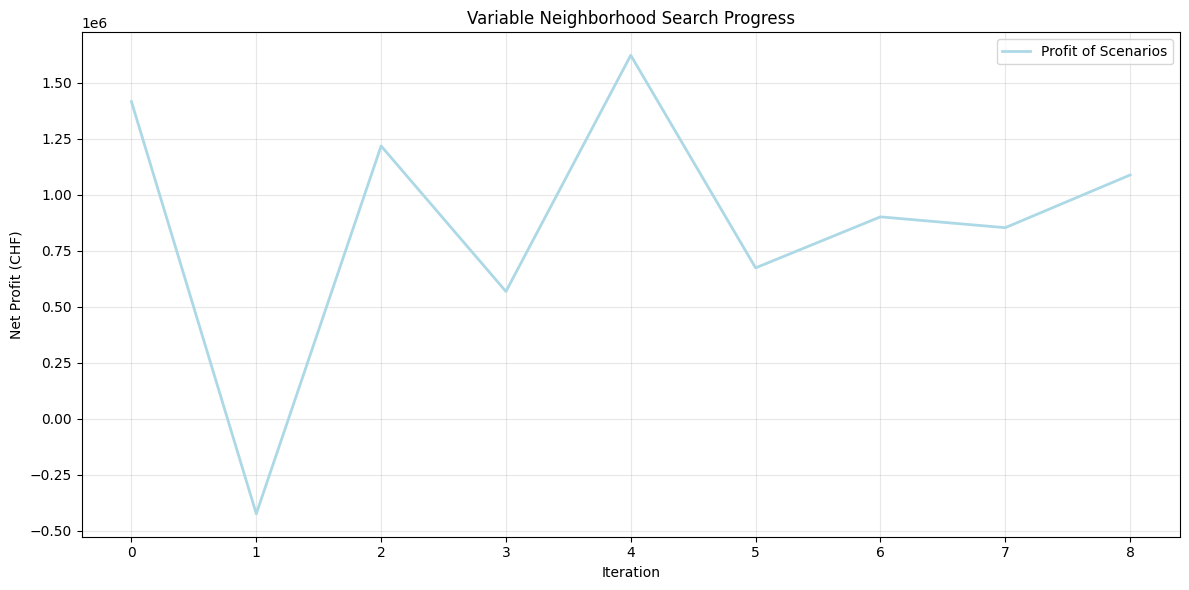

In [ ]:
# Analyze VNS results
print(f"Best scenario found:")
print(f"  Peak frequency: {best_scenario.train_frequency_peak} min")
print(f"  Off-peak frequency: {best_scenario.train_frequency_offpeak} min")
print(
    f"  Train Type 1: {best_scenario.train_config_1.first_class_carriages} first class, "
    f"{best_scenario.train_config_1.second_class_carriages} second class"
)
print(f"\nBest profit: {best_profit:.2f} CHF")
print(f"Total scenarios evaluated: {len(history)}")

# Plot the search history
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    [entry["profit"] for entry in history],
    color="lightblue",
    linewidth=2,
    label="Profit of Scenarios",
)

ax.set_xlabel("Iteration")
ax.set_ylabel("Net Profit (CHF)")
ax.set_title("Variable Neighborhood Search Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()